# Four Lenses on an Outbreak

*A small respiratory outbreak in a town of 1,000 people, modeled four ways.*

A single scenario, four simulation methods, four different things you can see. The point of this notebook is to show **when each method is the right tool**, by running them all on the same problem and watching what each one reveals - and what it hides.

| Lens | Question it answers | Cost |
|---|---|---|
| **ODE (SIR)** | Roughly how big will the outbreak get, on average? | Milliseconds |
| **Decision Tree** | Should we mass-vaccinate? What's the expected cost of each choice? | Microseconds |
| **DES (clinic)** | Can our clinic handle the surge of sick people? | Seconds |
| **ABM (network)** | Could the outbreak fizzle out? Who gets hit hardest? | Minutes |

The scenario is in [`scenario.py`](scenario.py); each lens lives in its own module.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scenario import DEFAULT as S
import ode_sir, decision_tree, des_clinic, abm_network

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print(f"Town: N={S.N}, R0={S.R0}, infectious period={S.infectious_days} days")
print(f"Clinic: {S.clinic_servers} doctor, {S.service_minutes:.0f} min/visit "
      f"-> ~{24*60/S.service_minutes:.0f} patients/day capacity")
print(f"Vaccine: {S.achievable_coverage:.0%} coverage x {S.vaccine_effectiveness:.0%} effective")

Town: N=1000, R0=2.0, infectious period=5.0 days
Clinic: 1 doctor, 90 min/visit -> ~16 patients/day capacity
Vaccine: 70% coverage x 90% effective


## Lens 1: ODE - the textbook SIR model

The SIR ODE compresses the entire town into three numbers - the count of susceptible, infected, and removed people - and lets them flow into each other at rates set by $\beta$ and $\gamma$. It's the workhorse of population-level epidemiology because it is *fast*, *smooth*, and *transparent*.

$$
\frac{dS}{dt} = -\beta\,\frac{SI}{N},\quad
\frac{dI}{dt} = \beta\,\frac{SI}{N} - \gamma I,\quad
\frac{dR}{dt} = \gamma I
$$

**Use it when** you need a fast answer for the average case and your population is large and well-mixed.

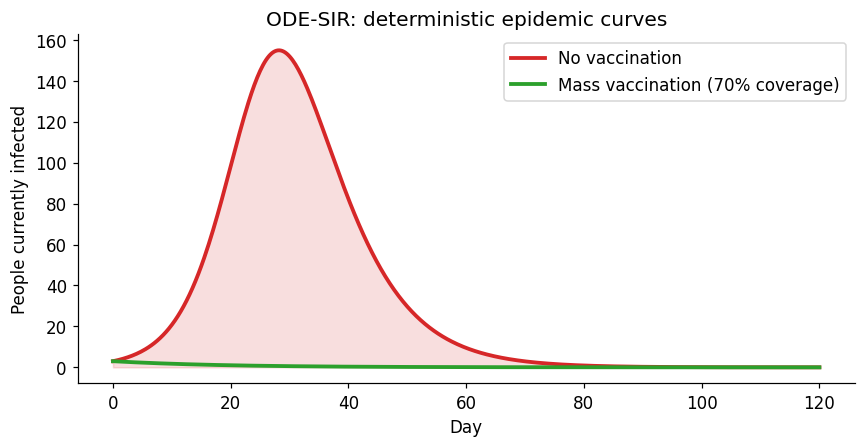

No vaccination -> peak 155 infected on day 28; final total 798
With vaccination -> peak 3; final total 11


In [2]:
ode_nv = ode_sir.simulate(S, vaccinated=False)
ode_v  = ode_sir.simulate(S, vaccinated=True)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(ode_nv['t'], ode_nv['I'], color='#d62728', lw=2.5, label='No vaccination')
ax.plot(ode_v['t'],  ode_v['I'],  color='#2ca02c', lw=2.5, label='Mass vaccination (70% coverage)')
ax.fill_between(ode_nv['t'], 0, ode_nv['I'], alpha=0.15, color='#d62728')
ax.set_xlabel('Day'); ax.set_ylabel('People currently infected')
ax.set_title('ODE-SIR: deterministic epidemic curves')
ax.legend(); plt.tight_layout()
plt.savefig('figures/01_ode.png', dpi=120); plt.show()

print(f"No vaccination -> peak {ode_nv['peak_prevalence']:.0f} infected on day {ode_nv['peak_day']:.0f}; "
      f"final total {ode_nv['total_infected']:.0f}")
print(f"With vaccination -> peak {ode_v['peak_prevalence']:.0f}; final total {ode_v['total_infected']:.0f}")

The ODE is unambiguous: do nothing and 80% of the town gets sick; vaccinate and the outbreak collapses. But that "collapses" hides a lot. The ODE has *no notion* of an individual, a queue, a network, or a coin flip. It will tell the same story every time you run it.

## Lens 2: Decision Tree - cost-effectiveness of the policy choice

The mayor doesn't care about $I(t)$ curves; she cares about dollars and doses. The decision tree wraps the ODE in a policy frame: branches for each choice, branches for each chance outcome, payoffs at the leaves, and a single number - expected cost - to compare.

**Use it when** the choice is one-shot, the outcomes are roughly discrete, and you can defend the probabilities at each branch.

In [3]:
tree = decision_tree.build_tree(S, extinction_prob_no_vax=0.0, extinction_prob_vax=0.0)
summary = decision_tree.summarize(tree)
for opt in summary['options']:
    print(f"{opt['label']:<18s}  expected cost = ${opt['expected_cost']:>10,.0f}")
print(f"\nRecommended: {summary['best']}")

Do nothing          expected cost = $   697,211
Mass-vaccinate      expected cost = $    35,000

Recommended: Mass-vaccinate


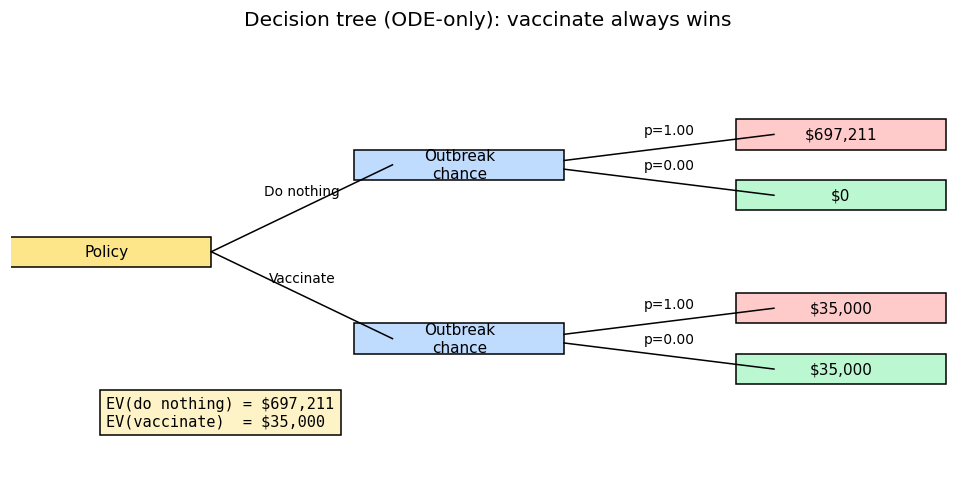

In [4]:
# Draw the tree
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

def box(x, y, text, color='#eeeeee', w=2.2, h=0.7):
    ax.add_patch(plt.Rectangle((x - w/2, y - h/2), w, h, fc=color, ec='black'))
    ax.text(x, y, text, ha='center', va='center', fontsize=10)

def line(x0, y0, x1, y1, lbl=None, lblcolor='black'):
    ax.plot([x0, x1], [y0, y1], 'k-', lw=1)
    if lbl:
        ax.text((x0+x1)/2, (y0+y1)/2 + 0.3, lbl, fontsize=9, ha='center', color=lblcolor)

box(1, 5, 'Policy', color='#fde68a')

# Branch: Do nothing
line(2.1, 5, 4, 7, 'Do nothing')
box(4.7, 7, 'Outbreak\nchance', color='#bfdbfe')
line(5.8, 7.1, 8, 7.7, 'p=1.00')
box(8.7, 7.7, f"${summary['options'][0]['leaves'][0]['cost']:,.0f}", color='#fecaca')
line(5.8, 6.9, 8, 6.3, 'p=0.00')
box(8.7, 6.3, '$0', color='#bbf7d0')

# Branch: Vaccinate
line(2.1, 5, 4, 3, 'Vaccinate')
box(4.7, 3, 'Outbreak\nchance', color='#bfdbfe')
line(5.8, 3.1, 8, 3.7, 'p=1.00')
box(8.7, 3.7, f"${summary['options'][1]['leaves'][0]['cost']:,.0f}", color='#fecaca')
line(5.8, 2.9, 8, 2.3, 'p=0.00')
box(8.7, 2.3, f"${summary['options'][1]['leaves'][1]['cost']:,.0f}", color='#bbf7d0')

ax.text(1, 1, f"EV(do nothing) = ${summary['options'][0]['expected_cost']:,.0f}\n"
              f"EV(vaccinate)  = ${summary['options'][1]['expected_cost']:,.0f}",
        fontsize=10, family='monospace',
        bbox=dict(facecolor='#fef3c7', edgecolor='black'))
plt.title('Decision tree (ODE-only): vaccinate always wins')
plt.tight_layout()
plt.savefig('figures/02_tree_ode.png', dpi=120); plt.show()

Right now the tree says vaccinating is a no-brainer because the ODE branch labeled "outbreak fizzles" has probability zero - the ODE never lets that happen. We'll come back and *fix that branch* using the ABM, which can see stochastic extinction.

## Lens 3: DES - what happens at the clinic when everyone shows up at once

The ODE counts cases. It doesn't count *exam rooms*. Discrete-event simulation does. We feed clinic arrivals using an inhomogeneous Poisson process driven by $\beta S I / N$ (a deliberate hand-off from the ODE - DES gives us the queue, ODE gives us the rate). A single doctor sees one patient at a time; everyone else waits.

**Use it when** the question is about flow, capacity, queues, or scheduling.

In [5]:
clinic_nv = des_clinic.simulate(S, vaccinated=False, seed=1)
clinic_v  = des_clinic.simulate(S, vaccinated=True,  seed=1)

print('No vaccination:'); print(' ', des_clinic.summarize(clinic_nv))
print('Mass vaccination:'); print(' ', des_clinic.summarize(clinic_v))

No vaccination:
  {'n_served': 566, 'n_arrivals': 566, 'mean_wait_hr': 78.11164608046977, 'p95_wait_hr': 154.5316573822125, 'max_queue': 109}
Mass vaccination:
  {'n_served': 8, 'n_arrivals': 8, 'mean_wait_hr': 0.06638929929813009, 'p95_wait_hr': 0.34522435635027615, 'max_queue': 0}


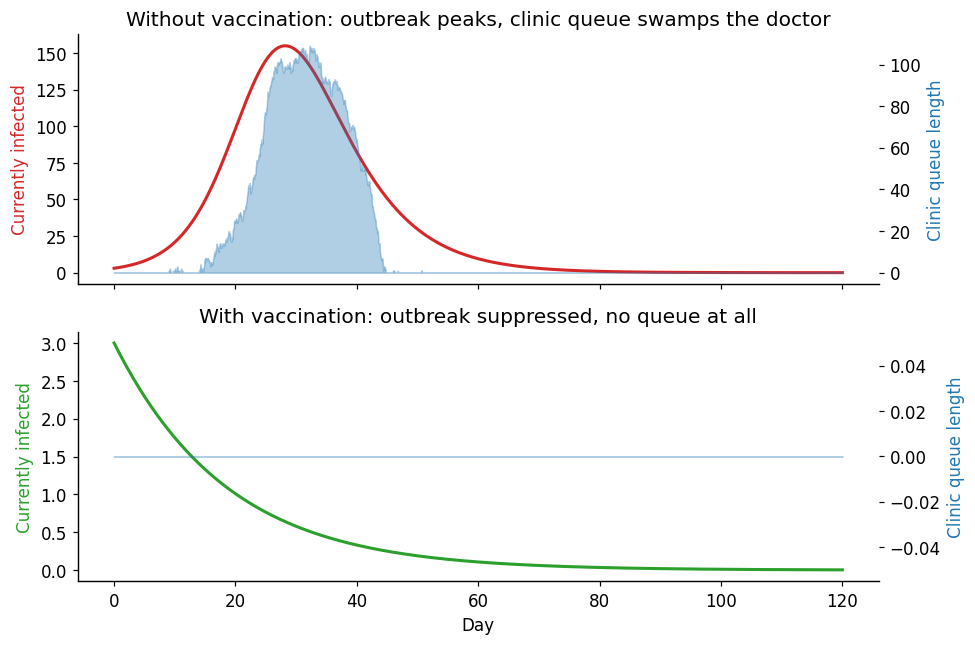

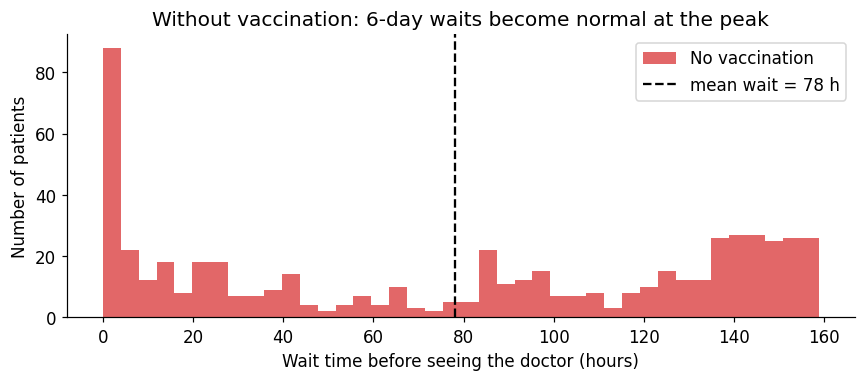

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: ODE infections vs DES queue length, no-vax
t_q  = np.array([t for t, _ in clinic_nv.queue_samples])
q_q  = np.array([q for _, q in clinic_nv.queue_samples])
ax = axes[0]
ax.plot(ode_nv['t'], ode_nv['I'], color='#d62728', lw=2, label='I(t) - ODE')
ax.set_ylabel('Currently infected', color='#d62728')
ax2 = ax.twinx(); ax2.spines['top'].set_visible(False)
ax2.fill_between(t_q, 0, q_q, color='#1f77b4', alpha=0.35, label='Clinic queue')
ax2.set_ylabel('Clinic queue length', color='#1f77b4')
ax.set_title('Without vaccination: outbreak peaks, clinic queue swamps the doctor')

# Bottom: same but with vaccination
t_q2  = np.array([t for t, _ in clinic_v.queue_samples])
q_q2  = np.array([q for _, q in clinic_v.queue_samples])
ax = axes[1]
ax.plot(ode_v['t'], ode_v['I'], color='#2ca02c', lw=2, label='I(t) - ODE')
ax.set_ylabel('Currently infected', color='#2ca02c')
ax2 = ax.twinx(); ax2.spines['top'].set_visible(False)
ax2.fill_between(t_q2, 0, q_q2, color='#1f77b4', alpha=0.35)
ax2.set_ylabel('Clinic queue length', color='#1f77b4')
ax.set_xlabel('Day')
ax.set_title('With vaccination: outbreak suppressed, no queue at all')

plt.tight_layout(); plt.savefig('figures/03_des.png', dpi=120); plt.show()

# Wait-time distribution
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(clinic_nv.waits_hours, bins=40, color='#d62728', alpha=0.7, label='No vaccination')
ax.axvline(np.mean(clinic_nv.waits_hours), color='black', lw=1.5, ls='--',
           label=f"mean wait = {np.mean(clinic_nv.waits_hours):.0f} h")
ax.set_xlabel('Wait time before seeing the doctor (hours)')
ax.set_ylabel('Number of patients')
ax.set_title('Without vaccination: 6-day waits become normal at the peak')
ax.legend(); plt.tight_layout()
plt.savefig('figures/04_waits.png', dpi=120); plt.show()

The ODE quietly assumed that 800 sick people could just *be* sick. The DES says: with one doctor and 90-minute visits, the clinic was 6 days behind at its worst. The same intervention that flattens the curve here also empties the waiting room - a public-health argument the ODE alone can't make.

## Lens 4: ABM - the outbreak might never happen

The ODE is deterministic. The decision tree borrowed its determinism. But epidemics on small populations are fundamentally *stochastic*: with three initial cases, sometimes the chain dies out on its own.

The ABM puts 1,000 agents on a small-world contact network. Each day, each infected agent rolls dice against every susceptible neighbor. We run it 200 times.

**Use it when** individuals, networks, or run-to-run variance change the answer; or when the system is too lumpy for "compartments" to capture.

In [7]:
N_RUNS = 200

abm_nv = abm_network.simulate_many(S, vaccinated=False, n_runs=N_RUNS, base_seed=42)
abm_v  = abm_network.simulate_many(S, vaccinated=True,  n_runs=N_RUNS, base_seed=42)

ext_nv = abm_network.extinction_probability(abm_nv)
ext_v  = abm_network.extinction_probability(abm_v)
print(f"No-vax: extinction probability = {ext_nv:.0%},  median total infected = {int(np.median([r.total_infected for r in abm_nv]))}")
print(f"Vax:    extinction probability = {ext_v:.0%},  median total infected = {int(np.median([r.total_infected for r in abm_v]))}")

No-vax: extinction probability = 24%,  median total infected = 447
Vax:    extinction probability = 98%,  median total infected = 6


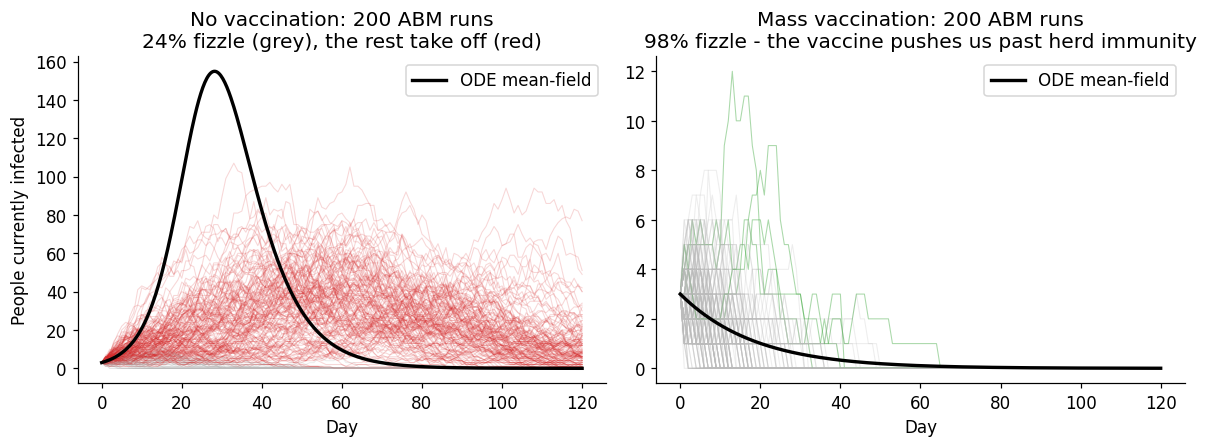

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
for r in abm_nv:
    color = '#bbb' if r.extinct else '#d62728'
    alpha = 0.25 if r.extinct else 0.18
    ax.plot(r.I, color=color, alpha=alpha, lw=0.7)
ax.plot(ode_nv['t'], ode_nv['I'], color='black', lw=2.2, label='ODE mean-field')
ax.set_title(f'No vaccination: {N_RUNS} ABM runs\n'
             f'{ext_nv:.0%} fizzle (grey), the rest take off (red)')
ax.set_xlabel('Day'); ax.set_ylabel('People currently infected'); ax.legend()

ax = axes[1]
for r in abm_v:
    color = '#bbb' if r.extinct else '#2ca02c'
    alpha = 0.25 if r.extinct else 0.4
    ax.plot(r.I, color=color, alpha=alpha, lw=0.7)
ax.plot(ode_v['t'], ode_v['I'], color='black', lw=2.2, label='ODE mean-field')
ax.set_title(f'Mass vaccination: {N_RUNS} ABM runs\n'
             f'{ext_v:.0%} fizzle - the vaccine pushes us past herd immunity')
ax.set_xlabel('Day'); ax.legend()
plt.tight_layout(); plt.savefig('figures/05_abm_spaghetti.png', dpi=120); plt.show()

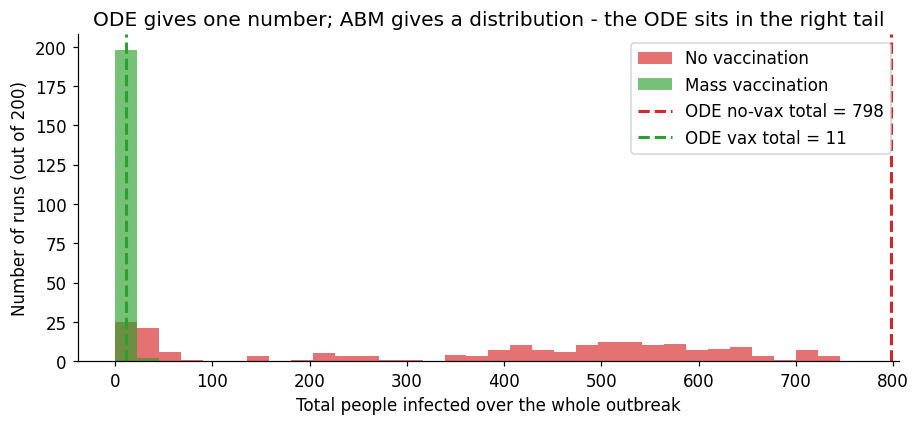

In [9]:
# Outcome distribution
fig, ax = plt.subplots(figsize=(8.5, 4))
totals_nv = [r.total_infected for r in abm_nv]
totals_v  = [r.total_infected for r in abm_v]
bins = np.linspace(0, max(totals_nv) + 30, 35)
ax.hist(totals_nv, bins=bins, color='#d62728', alpha=0.65, label='No vaccination')
ax.hist(totals_v,  bins=bins, color='#2ca02c', alpha=0.65, label='Mass vaccination')
ax.axvline(ode_nv['total_infected'], color='#d62728', ls='--', lw=2, label=f"ODE no-vax total = {ode_nv['total_infected']:.0f}")
ax.axvline(ode_v['total_infected'],  color='#2ca02c', ls='--', lw=2, label=f"ODE vax total = {ode_v['total_infected']:.0f}")
ax.set_xlabel('Total people infected over the whole outbreak')
ax.set_ylabel(f'Number of runs (out of {N_RUNS})')
ax.set_title('ODE gives one number; ABM gives a distribution - the ODE sits in the right tail')
ax.legend(); plt.tight_layout()
plt.savefig('figures/06_abm_distributions.png', dpi=120); plt.show()

Two things to notice:

1. **The ODE mean-field curve is not the average of the ABM curves.** It's a curve over a hypothetical world where the outbreak is guaranteed and contacts are uniform. The ABM mean sits well below it because (a) a quarter of runs fizzle entirely and (b) network clustering throttles spread even when it takes off.

2. **Extinction is a real probability.** Acting on the ODE alone, the mayor would never know that the most likely *single* outcome of "do nothing" is "nothing happens." A defensible policy has to weigh that.

## Putting it back together: a hybrid decision

The ABM gives us the one number the ODE could not: the probability the outbreak fizzles. Feed that into the decision tree and the recommendation may change.

In [10]:
tree2 = decision_tree.build_tree(
    S,
    extinction_prob_no_vax=ext_nv,
    extinction_prob_vax=ext_v,
)
summary2 = decision_tree.summarize(tree2)
rows = []
for opt in summary2['options']:
    rows.append({
        'option': opt['label'],
        'p(outbreak)': 1 - opt['leaves'][1]['prob'],
        'cost if outbreak': f"${opt['leaves'][0]['cost']:,.0f}",
        'cost if fizzles':  f"${opt['leaves'][1]['cost']:,.0f}",
        'expected cost':    f"${opt['expected_cost']:,.0f}",
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nRecommended (ABM-informed): {summary2['best']}")

        option  p(outbreak) cost if outbreak cost if fizzles expected cost
    Do nothing        0.765         $697,211              $0      $533,366
Mass-vaccinate        0.020          $35,000         $35,000       $35,000

Recommended (ABM-informed): Mass-vaccinate


The recommendation still favors vaccinating - the campaign's $35,000 cost is cheap compared to even one moderate-sized outbreak - but the *margin* has shrunk, and a tighter scenario (lower R0, smaller initial seed, costlier vaccine) could easily flip it. A decision tree built on ODE numbers alone would never have told you that.

## Side-by-side: peak prevalence

A single figure that shows what each method "sees" at the peak of the outbreak.

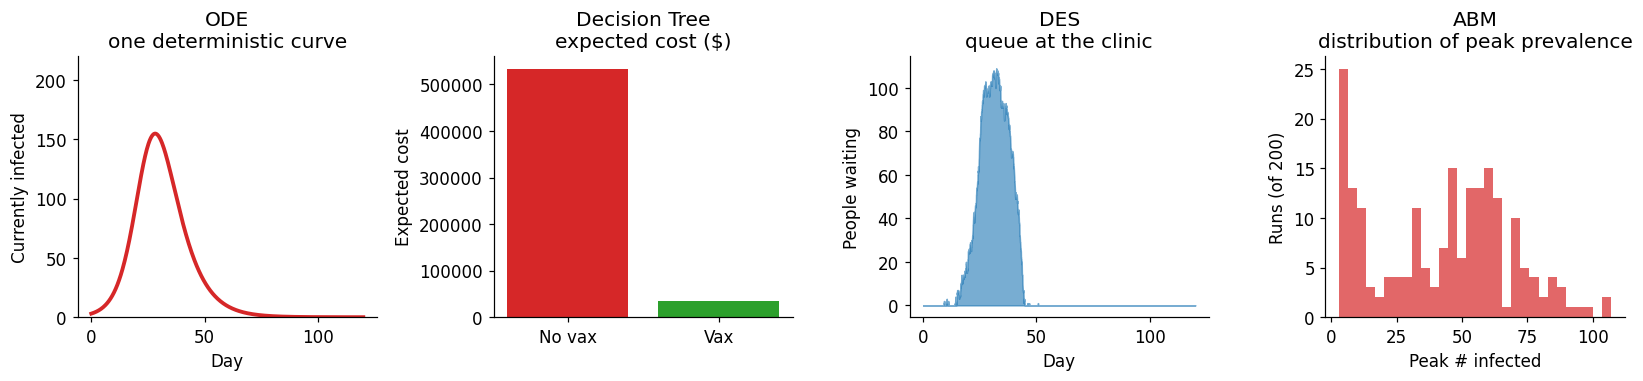

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))

# ODE - one curve
ax = axes[0]
ax.plot(ode_nv['t'], ode_nv['I'], color='#d62728', lw=2.5)
ax.set_title('ODE\none deterministic curve')
ax.set_ylabel('Currently infected')
ax.set_xlabel('Day'); ax.set_ylim(0, max(ode_nv['I'].max(), 200) * 1.1)

# Decision tree - two bars
ax = axes[1]
labels = ['No vax', 'Vax']
costs = [s['expected_cost'] for s in summary2['options']]
ax.bar(labels, costs, color=['#d62728', '#2ca02c'])
ax.set_title('Decision Tree\nexpected cost ($)')
ax.set_ylabel('Expected cost')

# DES - queue at peak
ax = axes[2]
ax.fill_between(t_q, 0, q_q, color='#1f77b4', alpha=0.6)
ax.set_title('DES\nqueue at the clinic')
ax.set_xlabel('Day'); ax.set_ylabel('People waiting')

# ABM - distribution
ax = axes[3]
ax.hist([r.peak_prevalence for r in abm_nv], bins=30, color='#d62728', alpha=0.7)
ax.set_title('ABM\ndistribution of peak prevalence')
ax.set_xlabel('Peak # infected'); ax.set_ylabel(f'Runs (of {N_RUNS})')

plt.tight_layout(); plt.savefig('figures/07_side_by_side.png', dpi=120); plt.show()

## When to reach for which lens

| If your question is... | Use | Why |
|---|---|---|
| How big, on average, and how fast can I find out? | **ODE** | Closed-form, transparent, milliseconds. |
| Which discrete policy should I pick? | **Decision Tree** | Frames choices and probabilities explicitly. |
| Can the system *handle* the load? | **DES** | Queues, resources, and scheduling are first-class. |
| Could things go very differently? Who's at risk? | **ABM** | Individuals, networks, and variance. |
| All of the above for one real decision | **Hybrid** | ODE -> probabilities -> tree; DES -> capacity check; ABM -> stress test. |

A practical recipe: **start with the ODE** to bound the answer, **draw the decision tree** to clarify the choice, **run the DES** to check that the recommended option doesn't break operational reality, and **run the ABM** to see if the recommended option is robust to stochasticity and structure. None of these models is a substitute for the others; they are different *lenses*, and the work is choosing the right one for the question in front of you.